In [43]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [44]:
df_1 = pd.read_csv('train.csv')
df_2 = pd.read_csv('test.csv')

In [45]:
if 'SalePrice' not in df_2.columns:
    df_2['SalePrice'] = 0

df = pd.concat([df_1, df_2], axis = 0)
df = df.set_index('Id')

In [46]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [47]:
df.isnull().sum()

MSSubClass         0
MSZoning           4
LotFrontage      486
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [48]:
df_null = df[df.isnull().sum()[df.isnull().sum() > 0].index]

In [49]:
df_null.head()

,MSZoning,LotFrontage,Alley,Utilities,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,...,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PoolQC,Fence,MiscFeature,SaleType
Id,,,,,,,,,,,,,,,,,,,,,
1,RL,65.0,NaN,AllPub,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,...,2003.0,RFn,2.0,548.0,TA,TA,NaN,NaN,NaN,WD
2,RL,80.0,NaN,AllPub,MetalSd,MetalSd,NaN,0.0,Gd,TA,...,1976.0,RFn,2.0,460.0,TA,TA,NaN,NaN,NaN,WD
3,RL,68.0,NaN,AllPub,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,...,2001.0,RFn,2.0,608.0,TA,TA,NaN,NaN,NaN,WD
4,RL,60.0,NaN,AllPub,Wd Sdng,Wd Shng,NaN,0.0,TA,Gd,...,1998.0,Unf,3.0,642.0,TA,TA,NaN,NaN,NaN,WD
5,RL,84.0,NaN,AllPub,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,...,2000.0,RFn,3.0,836.0,TA,TA,NaN,NaN,NaN,WD


<Axes: ylabel='Id'>

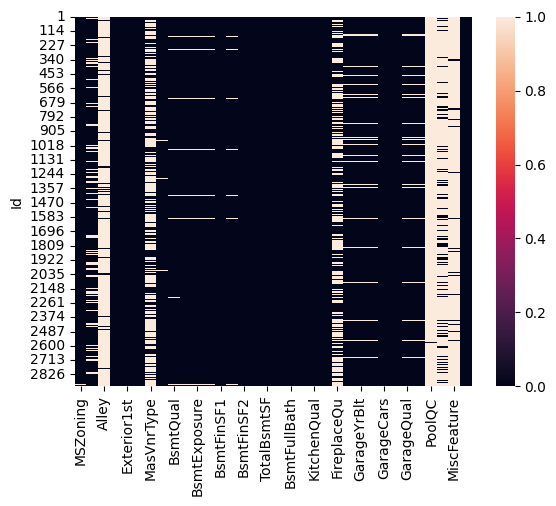

In [50]:
sns.heatmap(df_null.isnull())

In [51]:
df_objects = df[df.select_dtypes(include=['object']).columns]

In [52]:
df = df.drop(df[df_objects.isna().sum()[df_objects.isna().sum() > 1100].index], axis=1)

In [53]:
df_objects = df_objects.drop(df_objects[df_objects.isna().sum()[df_objects.isna().sum() > 1100].index], axis=1)

df_objects = df_objects.fillna('null')

df_objects_encoded = pd.get_dummies(df_objects)

In [54]:
df_objects['Utilities'].value_counts()

Utilities
AllPub    2916
null         2
NoSeWa       1
Name: count, dtype: int64

In [55]:
for i in df_objects_encoded.columns:
    if 'null' in i:
        df_objects_encoded = df_objects_encoded.drop(i, axis=1)
        print(i)

MSZoning_null
Utilities_null
Exterior1st_null
Exterior2nd_null
BsmtQual_null
BsmtCond_null
BsmtExposure_null
BsmtFinType1_null
BsmtFinType2_null
Electrical_null
KitchenQual_null
Functional_null
GarageType_null
GarageFinish_null
GarageQual_null
GarageCond_null
SaleType_null


In [56]:
new_df = pd.concat([df, df_objects_encoded], axis = 1)

In [57]:
len(new_df.columns)

304

In [58]:
len(df.columns), len(df_objects_encoded.columns)

(74, 230)

In [59]:
new_df = new_df.drop(df.select_dtypes(include=['object']), axis=1)

new_df.isna().sum()[new_df.isna().sum() > 0]

LotFrontage     486
MasVnrArea       23
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
GarageYrBlt     159
GarageCars        1
GarageArea        1
dtype: int64

In [60]:
Mode_columns = ['GarageCars', 'GarageYrBlt', 'BsmtFullBath', 'BsmtHalfBath']

Mean_columns = ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageArea']

In [61]:
for i in Mode_columns:
    new_df[i] = new_df[i].fillna(new_df[i].mode()[0])

In [62]:
for i in Mean_columns:
    new_df[i] = new_df[i].fillna(np.round(new_df[i].mean()))

In [63]:
new_df.isna().sum()[new_df.isna().sum() > 0]

Series([], dtype: int64)

In [64]:
training_data = new_df[0:len(df_1)]
testing_data = new_df[len(df_1):]
testing_data = testing_data.drop(columns='SalePrice')

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [66]:
X = training_data.drop(columns='SalePrice')
y = training_data['SalePrice']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
y_train = np.reshape(y_train, (-1, 1))
y_test = np.reshape(y_test, (-1, 1))

In [68]:
X_train.shape, y_train.shape

((1168, 266), (1168, 1))

In [69]:
model_1 = LinearRegression()
model_2 = RandomForestRegressor()
model_3 = XGBRegressor()

In [70]:
model_1.fit(X, y)
y_pred = model_1.predict(X_test)
mean_squared_error(y_test, y_pred)

288911238.9816558

In [42]:
model_2 = RandomForestRegressor(n_estimators=100)
model_2.fit(X, y)
y_pred = model_2.predict(X_test)
mean_squared_error(y_test, y_pred)

104817999.26977567

In [72]:
model_3 = XGBRegressor(n_estimators=1000, learning_rate=0.1, random_state=42)
model_3.fit(X, y)
y_pred = model_3.predict(X_test)
mean_squared_error(y_test, y_pred)

4379.56787109375

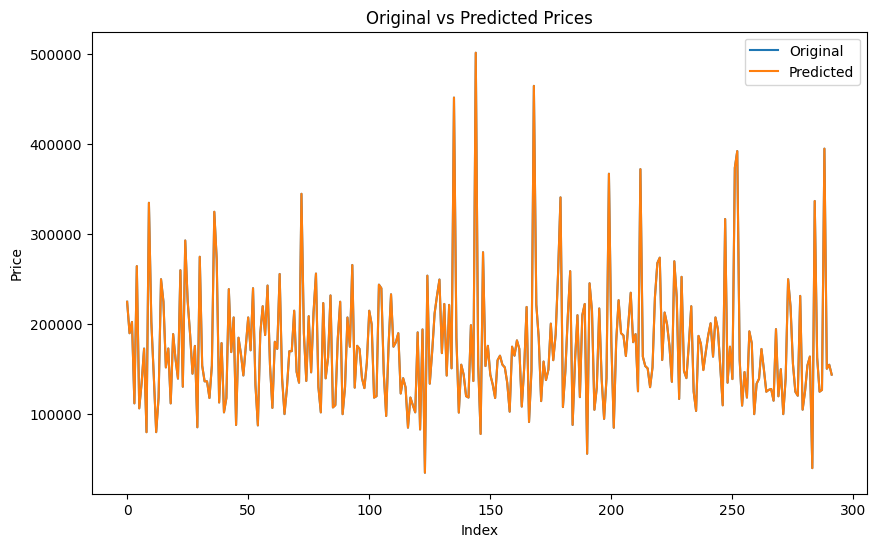

In [73]:
sort_indices = np.argsort(y_test)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test, label='Original')
plt.plot(np.arange(len(y_test)), y_pred, label='Predicted')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Original vs Predicted Prices')
plt.legend()
plt.show()

In [74]:
pred = model_3.predict(testing_data)

final = pd.DataFrame()
final['Id'] = testing_data.index
final['SalePrice'] = pred

final.to_csv('output.csv', index=False)